In [1]:
%cd ../
import pandas as pd
from src.finance.time_value import future_value, present_value, real_return

/home/gaelsf/venvs/science/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/gaelsf/Projects/financial-lab


In [2]:
rates = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]

pv = 10000
periods = 10

data = []

for rate in rates:
    fv = future_value(pv, rate, periods)
    
    data.append({
        "rate": rate,
        "periods": periods,
        "present_value": pv,
        "future_value": fv
    })

df = pd.DataFrame(data)

df

,rate,periods,present_value,future_value
0,0.02,10,10000,12189.944200
1,0.04,10,10000,14802.442849
2,0.06,10,10000,17908.476965
3,0.08,10,10000,21589.249973
4,0.10,10,10000,25937.424601
5,0.12,10,10000,31058.482083


In [3]:
df["profit"] = df["future_value"] - df["present_value"]
df

,rate,periods,present_value,future_value,profit
0,0.02,10,10000,12189.944200,2189.944200
1,0.04,10,10000,14802.442849,4802.442849
2,0.06,10,10000,17908.476965,7908.476965
3,0.08,10,10000,21589.249973,11589.249973
4,0.10,10,10000,25937.424601,15937.424601
5,0.12,10,10000,31058.482083,21058.482083


In [4]:
df[["rate", "profit"]]

,rate,profit
0,0.02,2189.944200
1,0.04,4802.442849
2,0.06,7908.476965
3,0.08,11589.249973
4,0.10,15937.424601
5,0.12,21058.482083


In [5]:
df["future_value"].max()

np.float64(31058.48208344212)

In [6]:
df.loc[df["future_value"].idxmax()]

rate                 0.120000
periods             10.000000
present_value    10000.000000
future_value     31058.482083
profit           21058.482083
Name: 5, dtype: float64

In [7]:
df[df["rate"]==0.08]
df["profit"].loc[df["rate"]==0.1]
df["future_value"].mean()

np.float64(20581.003445288265)

In [8]:
df["profit"].loc[df["rate"]==0.1]

4    15937.424601
Name: profit, dtype: float64

In [9]:
df["future_value"].mean()

np.float64(20581.003445288265)

In [10]:
rates = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12]
inflation_rates = [0.03, 0.05, 0.08]

pv = 10000
periods = 10

data = []

for rate in rates:
    for inflation in inflation_rates:

        real_r = real_return(rate, inflation)
        fv = future_value(pv, real_r, periods)
    
        data.append({
            "rate": rate,
            "inflation": inflation,
            "real_return": real_r,
            "future_value": fv
        })

df = pd.DataFrame(data)

df

,rate,inflation,real_return,future_value
0,0.02,0.03,-0.009709,9070.463302
1,0.02,0.05,-0.028571,7483.568304
2,0.02,0.08,-0.055556,5646.302774
3,0.04,0.03,0.009709,11014.407650
4,0.04,0.05,-0.009524,9087.415850
5,0.04,0.08,-0.037037,6856.395135
6,0.06,0.03,0.029126,13325.588735
7,0.06,0.05,0.009524,10994.251360
8,0.06,0.08,-0.018519,8295.089912
9,0.08,0.03,0.048544,16064.429532


In [11]:
data = []

for rate in rates:
    for inflation in inflation_rates:

        real_r = real_return(rate, inflation)

        fv_nominal = future_value(pv, rate, periods)

        purchasing_power = fv_nominal / (1 + inflation) ** periods

        data.append({
            "rate": rate,
            "inflation": inflation,
            "real_return": real_r,
            "future_value_nominal": fv_nominal,
            "purchasing_power": purchasing_power
        })

df = pd.DataFrame(data)
df

,rate,inflation,real_return,future_value_nominal,purchasing_power
0,0.02,0.03,-0.009709,12189.944200,9070.463302
1,0.02,0.05,-0.028571,12189.944200,7483.568304
2,0.02,0.08,-0.055556,12189.944200,5646.302774
3,0.04,0.03,0.009709,14802.442849,11014.407650
4,0.04,0.05,-0.009524,14802.442849,9087.415850
5,0.04,0.08,-0.037037,14802.442849,6856.395135
6,0.06,0.03,0.029126,17908.476965,13325.588735
7,0.06,0.05,0.009524,17908.476965,10994.251360
8,0.06,0.08,-0.018519,17908.476965,8295.089912
9,0.08,0.03,0.048544,21589.249973,16064.429532


In [12]:
df[df["real_return"] < 0]

,rate,inflation,real_return,future_value_nominal,purchasing_power
0,0.02,0.03,-0.009709,12189.944200,9070.463302
1,0.02,0.05,-0.028571,12189.944200,7483.568304
2,0.02,0.08,-0.055556,12189.944200,5646.302774
4,0.04,0.05,-0.009524,14802.442849,9087.415850
5,0.04,0.08,-0.037037,14802.442849,6856.395135
8,0.06,0.08,-0.018519,17908.476965,8295.089912


In [13]:
df.loc[df["purchasing_power"].idxmax()]

rate                        0.120000
inflation                   0.030000
real_return                 0.087379
future_value_nominal    31058.482083
purchasing_power        23110.427524
Name: 15, dtype: float64

In [14]:
df.loc[df["purchasing_power"].idxmin()]

rate                        0.020000
inflation                   0.080000
real_return                -0.055556
future_value_nominal    12189.944200
purchasing_power         5646.302774
Name: 2, dtype: float64

In [15]:
cols = ["inflation","real_return","purchasing_power"]
df[df["rate"]==0.08][cols]

,inflation,real_return,purchasing_power
9,0.03,0.048544,16064.429532
10,0.05,0.028571,13253.926692
11,0.08,0.000000,10000.000000


In [16]:
df

,rate,inflation,real_return,future_value_nominal,purchasing_power
0,0.02,0.03,-0.009709,12189.944200,9070.463302
1,0.02,0.05,-0.028571,12189.944200,7483.568304
2,0.02,0.08,-0.055556,12189.944200,5646.302774
3,0.04,0.03,0.009709,14802.442849,11014.407650
4,0.04,0.05,-0.009524,14802.442849,9087.415850
5,0.04,0.08,-0.037037,14802.442849,6856.395135
6,0.06,0.03,0.029126,17908.476965,13325.588735
7,0.06,0.05,0.009524,17908.476965,10994.251360
8,0.06,0.08,-0.018519,17908.476965,8295.089912
9,0.08,0.03,0.048544,21589.249973,16064.429532


<Axes: xlabel='rate'>

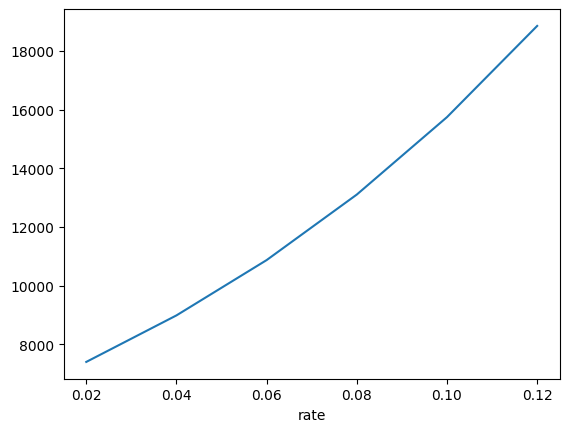

In [18]:
df.groupby("rate")["purchasing_power"].mean().plot()

In [19]:
df.groupby("rate")["purchasing_power"].mean()

rate
0.02     7400.111460
0.04     8986.072878
0.06    10871.643336
0.08    13106.118741
0.10    15745.751571
0.12    18854.575987
Name: purchasing_power, dtype: float64

<Axes: title={'center': 'Poder adquisitivo vs tasa de inversión'}, xlabel='rate'>

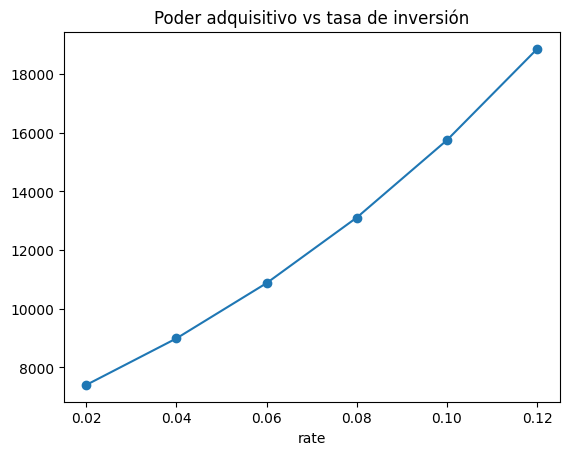

In [20]:
avg_pp = df.groupby("rate")["purchasing_power"].mean()

avg_pp.plot(kind='line', marker = 'o', title = 'Poder adquisitivo vs tasa de inversión')

In [21]:
import numpy as np

rates = np.arange(0.01, 0.151, 0.01)
inflation_rates = np.arange(0.01, 0.151, 0.01)

len(rates), len(inflation_rates)

(15, 15)

In [22]:
data = []

for rate in rates:
    for inflation in inflation_rates:

        real_r = real_return(rate, inflation)

        fv_nominal = future_value(pv, rate, periods)

        purchasing_power = (
            fv_nominal / (1 + inflation) ** periods
        )

        data.append({
            "rate": rate,
            "inflation": inflation,
            "real_return": real_r,
            "future_value_nominal": fv_nominal,
            "purchasing_power": purchasing_power
        })

df_sensitivity = pd.DataFrame(data)

df_sensitivity.head()

,rate,inflation,real_return,future_value_nominal,purchasing_power
0,0.01,0.01,0.000000,11046.221254,10000.000000
1,0.01,0.02,-0.009804,11046.221254,9061.748826
2,0.01,0.03,-0.019417,11046.221254,8219.426018
3,0.01,0.04,-0.028846,11046.221254,7462.431280
4,0.01,0.05,-0.038095,11046.221254,6781.421629


In [24]:
df_sensitivity.shape

(225, 5)

In [25]:
positive_real = df_sensitivity[
    df_sensitivity["real_return"] > 0
]

positive_real.shape

(105, 5)

In [26]:
len(positive_real) / len(df_sensitivity)

0.4666666666666667

In [27]:
df_sensitivity[
    np.isclose(df_sensitivity["real_return"], 0)
]

,rate,inflation,real_return,future_value_nominal,purchasing_power
0,0.01,0.01,0.0,11046.221254,10000.0
16,0.02,0.02,0.0,12189.944200,10000.0
32,0.03,0.03,0.0,13439.163793,10000.0
48,0.04,0.04,0.0,14802.442849,10000.0
64,0.05,0.05,0.0,16288.946268,10000.0
80,0.06,0.06,0.0,17908.476965,10000.0
96,0.07,0.07,0.0,19671.513573,10000.0
112,0.08,0.08,0.0,21589.249973,10000.0
128,0.09,0.09,0.0,23673.636746,10000.0
144,0.10,0.10,0.0,25937.424601,10000.0


In [28]:
real_return_matrix = df_sensitivity.pivot_table(
    index="inflation",
    columns="rate",
    values="real_return"
)

real_return_matrix

rate,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.10,0.11,0.12,0.13,0.14,0.15
inflation,,,,,,,,,,,,,,,
0.01,0.000000,0.009901,0.019802,0.029703,0.039604,0.049505,0.059406,0.069307,0.079208,0.089109,0.099010,0.108911,0.118812,0.128713,0.138614
0.02,-0.009804,0.000000,0.009804,0.019608,0.029412,0.039216,0.049020,0.058824,0.068627,0.078431,0.088235,0.098039,0.107843,0.117647,0.127451
0.03,-0.019417,-0.009709,0.000000,0.009709,0.019417,0.029126,0.038835,0.048544,0.058252,0.067961,0.077670,0.087379,0.097087,0.106796,0.116505
0.04,-0.028846,-0.019231,-0.009615,0.000000,0.009615,0.019231,0.028846,0.038462,0.048077,0.057692,0.067308,0.076923,0.086538,0.096154,0.105769
0.05,-0.038095,-0.028571,-0.019048,-0.009524,0.000000,0.009524,0.019048,0.028571,0.038095,0.047619,0.057143,0.066667,0.076190,0.085714,0.095238
0.06,-0.047170,-0.037736,-0.028302,-0.018868,-0.009434,0.000000,0.009434,0.018868,0.028302,0.037736,0.047170,0.056604,0.066038,0.075472,0.084906
0.07,-0.056075,-0.046729,-0.037383,-0.028037,-0.018692,-0.009346,0.000000,0.009346,0.018692,0.028037,0.037383,0.046729,0.056075,0.065421,0.074766
0.08,-0.064815,-0.055556,-0.046296,-0.037037,-0.027778,-0.018519,-0.009259,0.000000,0.009259,0.018519,0.027778,0.037037,0.046296,0.055556,0.064815
0.09,-0.073394,-0.064220,-0.055046,-0.045872,-0.036697,-0.027523,-0.018349,-0.009174,0.000000,0.009174,0.018349,0.027523,0.036697,0.045872,0.055046


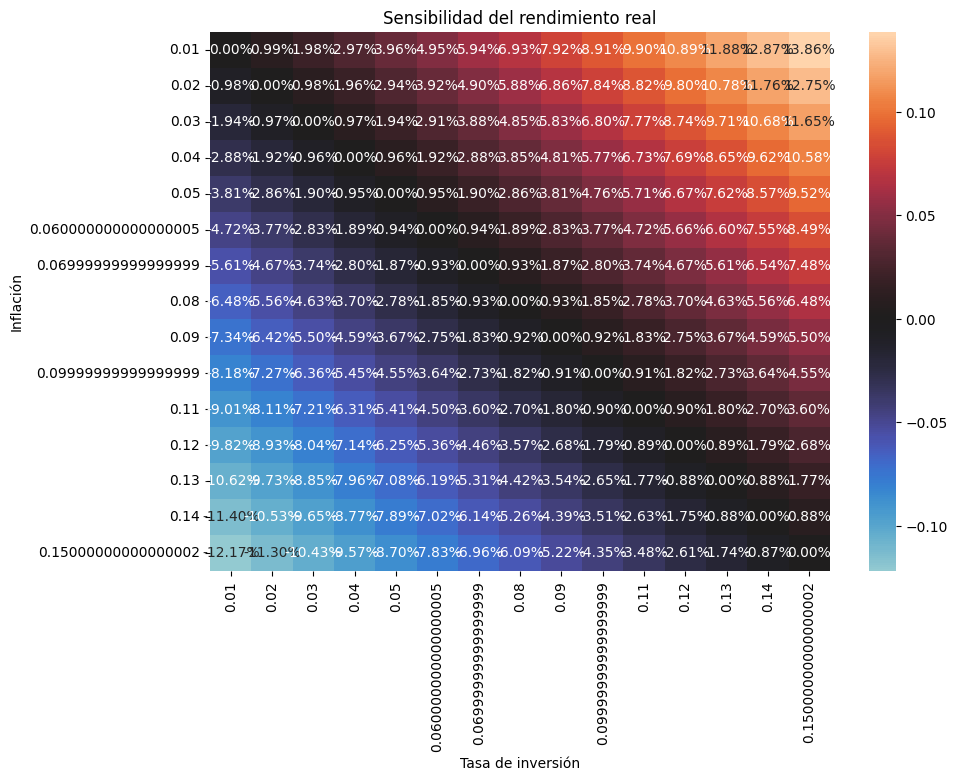

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    real_return_matrix,
    annot=True,
    fmt=".2%",
    center=0
)

plt.xlabel("Tasa de inversión")
plt.ylabel("Inflación")
plt.title("Sensibilidad del rendimiento real")
plt.show()

In [30]:
data = []
periods_list = [1, 10, 30]
rate = 0.08
inflation = 0.05

for period in periods_list:
    
    real_r = real_return(rate, inflation)

    fv_nominal = future_value(pv, rate, period)

    purchasing_power = fv_nominal / (1 + inflation) ** period

    data.append({
        "rate": rate,
        "inflation": inflation,
        "periods": period,
        "real_return": real_r,
        "future_value_nominal": fv_nominal,
        "purchasing_power": purchasing_power
    })

df = pd.DataFrame(data)
df

,rate,inflation,periods,real_return,future_value_nominal,purchasing_power
0,0.08,0.05,1,0.028571,10800.000000,10285.714286
1,0.08,0.05,10,0.028571,21589.249973,13253.926692
2,0.08,0.05,30,0.028571,100626.568891,23282.718777


In [33]:
cols = ["periods", "real_return", "purchasing_power"]
df[cols]

,periods,real_return,purchasing_power
0,1,0.028571,10285.714286
1,10,0.028571,13253.926692
2,30,0.028571,23282.718777
